In [24]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [25]:
Image_Size=[224,224]
trainMyImagesFolder="D:\DOWNLOAD FOLDER\alien_vs_predator_thumbnails\data\train"
testMyImagesFolder="D:\DOWNLOAD FOLDER\alien_vs_predator_thumbnails\data\validation"

In [26]:
myRestnet=ResNet50(input_shape=Image_Size + [3],weights="imagenet",include_top=False)
print(myRestnet.summary())

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


In [27]:
for layer in myRestnet.layers:
    layer.trainable=False

classes=glob(r'D:\DOWNLOAD FOLDER\alien_vs_predator_thumbnails\data\train\*')
print(classes)
numOfClasses=len(classes)

['D:\\DOWNLOAD FOLDER\\alien_vs_predator_thumbnails\\data\\train\\alien', 'D:\\DOWNLOAD FOLDER\\alien_vs_predator_thumbnails\\data\\train\\predator']


In [28]:
global_avg_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(myRestnet.output)
PlusFlattenLayer=Flatten()(global_avg_pooling_layer)

In [29]:
predictionLayer = Dense(numOfClasses, activation='softmax')(PlusFlattenLayer)
model = Model(inputs=myRestnet.input, outputs=predictionLayer)
print(model.summary())
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), metrics=['accuracy'])

train_datagem = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
test_datagem = ImageDataGenerator(rescale=1./255)

training_set = train_datagem.flow_from_directory(trainMyImagesFolder, target_size=(224,224), batch_size=32, class_mode='categorical')
test_set = test_datagem.flow_from_directory(testMyImagesFolder, target_size=(224,224), batch_size=32, class_mode='categorical')

print(training_set.class_indices) 


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: 'D:\\DOWNLOAD FOLDER\x07lien_vs_predator_thumbnails\\data\train'

In [30]:
import sys

variables_to_check = [
    'train_datagem', 'test_datagem',
    'trainMyImagesFolder', 'testMyImagesFolder',
    'training_set', 'test_set',
    'model', 'EPOCHS'
]

for var in variables_to_check:
    if var in dir():
        print(f"✅ {var} = {eval(var)}")
    else:
        print(f"❌ {var} is NOT defined")

✅ train_datagem = <keras.src.legacy.preprocessing.image.ImageDataGenerator object at 0x0000016108A5EF90>
✅ test_datagem = <keras.src.legacy.preprocessing.image.ImageDataGenerator object at 0x000001610FEA0890>
✅ trainMyImagesFolder = D:\DOWNLOAD FOLDERlien_vs_predator_thumbnails\data	rain
✅ testMyImagesFolder = D:\DOWNLOAD FOLDERlien_vs_predator_thumbnails\dataalidation
✅ training_set = <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x000001610B2E6110>
✅ test_set = <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x000001617FCE04D0>
✅ model = <Functional name=functional_2, built=True>
✅ EPOCHS = 10


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4482 - loss: 1.1726
Epoch 1: val_accuracy improved from None to 0.64500, saving model to D:\DOWNLOAD FOLDER\alien-predictor-model.keras

Epoch 1: finished saving model to D:\DOWNLOAD FOLDER\alien-predictor-model.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.5000 - loss: 0.9641 - val_accuracy: 0.6450 - val_loss: 0.6224 - learning_rate: 0.0100
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6430 - loss: 0.6348
Epoch 2: val_accuracy improved from 0.64500 to 0.67000, saving model to D:\DOWNLOAD FOLDER\alien-predictor-model.keras

Epoch 2: finished saving model to D:\DOWNLOAD FOLDER\alien-predictor-model.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.6398 - loss: 0.6410 - val_accuracy: 0.6700 - val_loss: 0.6190 - learning_rate: 0.0100
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6317 - loss: 0.6187
Epoch 3: val_accuracy improved from 0.67000 to 0.69500, saving model to D

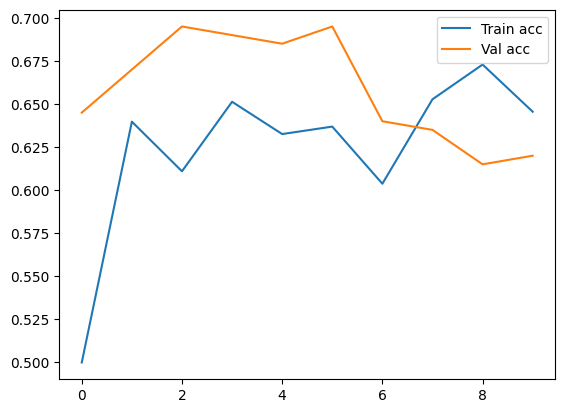

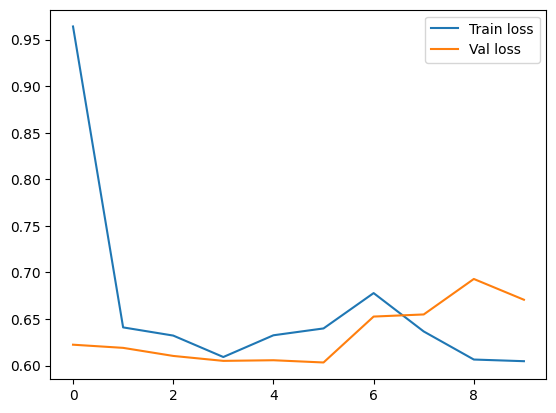

In [31]:
EPOCHS = 10
best_model_file =r'D:\DOWNLOAD FOLDER\alien-predictor-model.keras'

from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
callbacks = [
    ModelCheckpoint(best_model_file, verbose=1, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', patience=10, factor=0.1, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor='val_accuracy', patience=30, verbose=1)
]

r = model.fit(training_set, validation_data=test_set, epochs=EPOCHS,
              steps_per_epoch=len(training_set), validation_steps=len(test_set), callbacks=callbacks)

best_val_acc = max(r.history['val_accuracy'])
print(f"Best Validation Accuracy: {best_val_acc}")

plt.plot(r.history['accuracy'], label='Train acc')
plt.plot(r.history['val_accuracy'], label='Val acc')
plt.legend()
plt.show()

plt.plot(r.history['loss'], label='Train loss')
plt.plot(r.history['val_loss'], label='Val loss')
plt.legend()
plt.show()

In [32]:
trainMyImagesFolder = r"D:\DOWNLOAD FOLDER\alien_vs_predator_thumbnails\data\train"
testMyImagesFolder  = r"D:\DOWNLOAD FOLDER\alien_vs_predator_thumbnails\data\validation"
import os
print(os.path.exists(trainMyImagesFolder))
print(os.path.exists(testMyImagesFolder)) 

True
True


In [34]:
import tensorflow as tf
import cv2
import os
from keras.utils import load_img,img_to_array
import numpy as n
Image_Size=224


In [37]:
import torch.nn as nn

In [39]:
import os  # os.listdir is what you need

trainMyImageFolder = r"D:\DOWNLOAD FOLDER\alien_vs_predator_thumbnails\data\train"
classes = os.listdir(trainMyImageFolder)
num_classes = len(classes)
print(classes)      # ['alien', 'predator']
print(num_classes)  # 2

best_model_file = r'D:\DOWNLOAD FOLDER\alien-predictor-model.keras'
model = tf.keras.models.load_model(best_model_file)

def prepareImage(pathForImage):
    image = load_img(pathForImage, target_size=(Image_Size, Image_Size))
    imgResult = img_to_array(image)
    imgResult = np.expand_dims(imgResult, axis=0)
    imgResult = imgResult / 255.
    return imgResult

['alien', 'predator']
2


In [40]:
testImagePath='0.jpg'

In [43]:
img=cv2.imread(testImagePath)
imgForModel=prepareImage(testImagePath)
resultArray=model.predict(imgForModel,verbose=1)
print(resultArray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[[0.61063266 0.3893673 ]]


In [44]:
answer=np.argmax(resultArray,axis=1)
print(answer)

[0]


In [ ]:
index = np.argmax(resultArray[0])
className = classes[index]
confidence = resultArray[0][index] * 100

print(f"Predicted class: {className} ({confidence:.2f}%)")

cv2.putText(img, className, (200, 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
cv2.imshow("img", img)
cv2.waitKey(0)

Predicted class: alien (61.06%)
